<a href="https://colab.research.google.com/github/melissa-04/spatial-transcriptomics-learning-project/blob/main/notebooks/01_quality_control.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
! pip install -q squidpy
import scanpy as sc
import squidpy as sq
import numpy as np
import matplotlib.pyplot as plt

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 272.3/272.3 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.1/176.1 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.2/199.2 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.6/51.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 57.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12

/usr/local/lib/python3.12/dist-packages/docrep/decorators.py:43: SyntaxWarning: 'n_jobs' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/usr/local/lib/python3.12/dist-packages/docrep/decorators.py:43: SyntaxWarning: 'show_progress_bar' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


In [2]:
adata =sq.datasets.merfish()
print(adata)

INFO     Downloading merfish.h5ad from https://exampledata.scverse.org/squidpy/merfish.h5ad                        


  0%|                                              | 0.00/51.6M [00:00<?, ?B/s]

AnnData object with n_obs × n_vars = 73655 × 161
    obs: 'Cell_ID', 'Animal_ID', 'Animal_sex', 'Behavior', 'Bregma', 'Centroid_X', 'Centroid_Y', 'Cell_class', 'Neuron_cluster_ID', 'batch'
    uns: 'Cell_class_colors'
    obsm: 'spatial', 'spatial3d'


In [5]:
sc.pp.calculate_qc_metrics(adata, inplace=True, percent_top=None, log1p=False)
print("=== new obs columns ===")
print(adata.obs[["total_counts", "n_genes_by_counts"]].head())
print("\n=== summary od QC metrics ===")
print(adata.obs[["total_counts", "n_genes_by_counts"]].describe())

=== new obs columns ===
         total_counts  n_genes_by_counts
67146-0    228.319382                 17
67147-0    280.125244                 30
67148-0    272.853577                 87
67149-0    224.022308                 64
67150-0    296.911316                 39

=== summary od QC metrics ===
       total_counts  n_genes_by_counts
count  73655.000000       73655.000000
mean     250.184891          63.273030
std       72.420639          22.485537
min        0.134064           7.000000
25%      201.966995          45.000000
50%      250.985962          63.000000
75%      297.258606          81.000000
max     2042.139282         135.000000


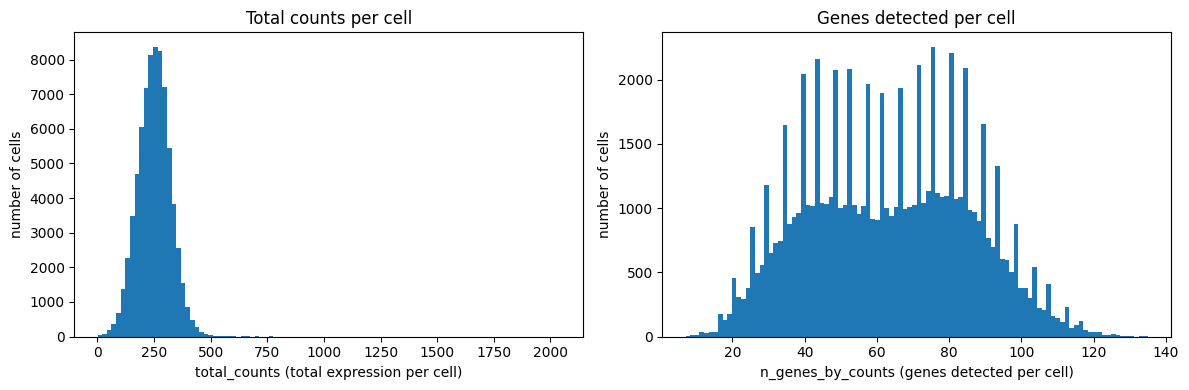

In [8]:
fig, axes=plt.subplots(1,2,figsize =(12,4))
# --- Left plot: total_counts ---
# .hist() draws a histogram. bins=100 splits the value range into 100 bars.
axes[0].hist(adata.obs["total_counts"], bins=100)
axes[0].set_xlabel("total_counts (total expression per cell)")
axes[0].set_ylabel("number of cells")
axes[0].set_title("Total counts per cell")

# --- Right plot: n_genes_by_counts ---
axes[1].hist(adata.obs["n_genes_by_counts"], bins=100)
axes[1].set_xlabel("n_genes_by_counts (genes detected per cell)")
axes[1].set_ylabel("number of cells")
axes[1].set_title("Genes detected per cell")
# tight_layout() neatly spaces the two plots so labels don't overlap.
plt.tight_layout()
plt.show()

In [9]:
n_before= adata.n_obs
keep = (
    (adata.obs["total_counts"] >= 20)
    & (adata.obs["total_counts"] <= 1000)
    & (adata.obs["n_genes_by_counts"] >= 10)
)

adata = adata[keep].copy()

# Report the result: how many removed, how many remain, and the percentage kept.
n_after = adata.n_obs
print(f"Cells before : {n_before}")
print(f"Cells removed: {n_before - n_after}")
print(f"Cells after  : {n_after}")
print(f"Kept         : {100 * n_after / n_before:.2f}%")

Cells before : 73655
Cells removed: 53
Cells after  : 73602
Kept         : 99.93%


In [10]:
# ── STEP 6.5: Save the filtered data to Google Drive ─────────────────

# This is a fresh notebook/session, so mount Drive and re-define paths.
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')

# Same project structure we set up in notebook 00.
PROJECT_DIR = Path("/content/drive/MyDrive/spatial_transcriptomics_project")
DATA_DIR = PROJECT_DIR / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)  # ensure it exists

# Save the filtered AnnData as an .h5ad file.
out_path = DATA_DIR / "merfish_qc.h5ad"
adata.write_h5ad(out_path)

print(f"Saved filtered data to: {out_path}")
print(f"Object: {adata.n_obs} cells x {adata.n_vars} genes")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved filtered data to: /content/drive/MyDrive/spatial_transcriptomics_project/data/merfish_qc.h5ad
Object: 73602 cells x 161 genes
